Checking data qualitites...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10240 entries, 0 to 10239
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Label                 10240 non-null  object 
 1   Statement             10240 non-null  object 
 2   Subject               10238 non-null  object 
 3   Speaker               10238 non-null  object 
 4   Speaker_Job           7342 non-null   object 
 5   State                 8030 non-null   object 
 6   Party                 10238 non-null  object 
 7   Barely_True_Counts    10238 non-null  float64
 8   False_Counts          10238 non-null  float64
 9   Half_True_Counts      10238 non-null  float64
 10  Mostly_True_Counts    10238 non-null  float64
 11  Pants_On_Fire_Counts  10238 non-null  float64
 12  Context               10138 non-null  object 
dtypes: float64(5), object(8)
memory usage: 1.0+ MB
check finished.
Checking data qualitites...
<c

Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  train_df['Statement'][x] = review
/tmp/ipykernel_5398/3558847196.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Statement'][x] = review
/tmp/ipykernel_5398/3558847196.py:83: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when yo

Accuracy: 21.62%
Confusion matrix, without normalization
--- Testing the model ---
News Statement 1: Donald Trump said that global warming is a hoax invented by China.
Prediction of the News :  Looking Fake⚠ News📰 


News Statement 2: President Biden signed the Infrastructure Investment and Jobs Act into law.
Prediction of the News :  Looking Fake⚠ News📰 

--- Testing another Real News Statement ---
News Statement 3: NASA's Perseverance Mars rover has collected its first rock samples.
Prediction of the News : Looking Real News📰 


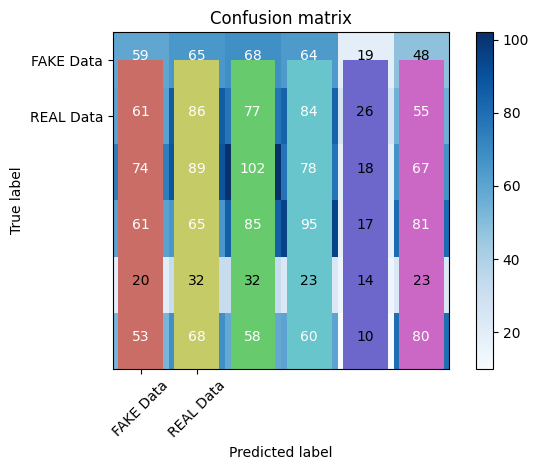

In [2]:
import pandas as pd
import sklearn
import itertools
import numpy as np
import seaborn as sb
import re
import nltk
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
from sklearn.linear_model import PassiveAggressiveClassifier
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

column_names = ['ID', 'Label', 'Statement', 'Subject', 'Speaker', 'Speaker_Job', 'State', 'Party', 'Barely_True_Counts', 'False_Counts', 'Half_True_Counts', 'Mostly_True_Counts', 'Pants_On_Fire_Counts', 'Context']
train_df = pd.read_csv(r'/train.tsv', sep='\t', header=None, names=column_names)

train_df.head(15)

train_df = train_df.drop("ID", axis = 1)

train_df.shape
train_df.head(15)

def create_distribution(dataFile):
    return sb.countplot(x='Label', data=dataFile, palette='hls', hue='Label', legend=False)

# by calling below we can see that training, test and valid data seems to be failry evenly distributed between the classes
create_distribution(train_df)

def data_qualityCheck():
    print("Checking data qualitites...")
    train_df.isnull().sum()
    train_df.info()
    print("check finished.")
data_qualityCheck()

train_df = train_df.dropna()
data_qualityCheck()

train_df.shape
train_df.head(10)

train_df.reset_index(drop= True,inplace=True)
train_df.head(10)

label_train = train_df['Label']
label_train.head(10)

train_df = train_df.drop("Label", axis = 1)
train_df.head(10)

train_df['Statement'][2188]

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
stpwrds = list(stopwords.words('english'))

stpwrds

from nltk.tokenize import TreebankWordTokenizer

# Initialize the TreebankWordTokenizer outside the loop for efficiency
tokenizer = TreebankWordTokenizer()

for x in range(len(train_df)) :
    corpus = []
    review = train_df['Statement'][x]
    review = re.sub(r'[^a-zA-Z\s]', '', review)
    review = review.lower()
    review = tokenizer.tokenize(review) # Using TreebankWordTokenizer here
    for y in review :
        if y not in stpwrds :
            corpus.append(lemmatizer.lemmatize(y))
    review = ' '.join(corpus)
    train_df['Statement'][x] = review

train_df['Statement'][2182]

X_train, X_test, Y_train, Y_test = train_test_split(train_df['Statement'], label_train, test_size=0.3, random_state=1)

X_train

X_train.shape

Y_train

tfidf_v = TfidfVectorizer()
tfidf_X_train = tfidf_v.fit_transform(X_train)
tfidf_X_test = tfidf_v.transform(X_test)

tfidf_X_train.shape

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

classifier = PassiveAggressiveClassifier()
classifier.fit(tfidf_X_train,Y_train)

Y_pred = classifier.predict(tfidf_X_test)
score = metrics.accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {round(score*100,2)}%')
cm = metrics.confusion_matrix(Y_test, Y_pred)
plot_confusion_matrix(cm, classes=['FAKE Data', 'REAL Data'])

pickle.dump(classifier,open('/content/model.pkl', 'wb'))

# load the model from disk
loaded_model = pickle.load(open('./model.pkl', 'rb'))

def fake_news_det(news):
    corpus = [] # Initialize corpus locally within the function
    review = news
    review = re.sub(r'[^a-zA-Z\s]', '', review)
    review = review.lower()
    # Use the global tokenizer instance (TreebankWordTokenizer) for consistency
    review = tokenizer.tokenize(review)
    for y in review :
        if y not in stpwrds :
            corpus.append(lemmatizer.lemmatize(y))
    input_data = [' '.join(corpus)]
    vectorized_input_data = tfidf_v.transform(input_data)
    prediction = loaded_model.predict(vectorized_input_data)

    # Map the multi-class prediction to binary 'Fake' or 'Real'
    if prediction[0] in ['false', 'barely-true', 'pants-fire']:
        print("Prediction of the News :  Looking Fake⚠ News📰 ")
    elif prediction[0] in ['half-true', 'mostly-true', 'true']:
        print("Prediction of the News : Looking Real News📰 ")
    else:
        # Fallback for unexpected labels or to indicate unknown
        print(f"Prediction of the News : Unknown category - {prediction[0]}")

print('--- Testing the model ---')
# Example 1: Potentially fake news
news_statement_1 = "Donald Trump said that global warming is a hoax invented by China."
print("News Statement 1:", news_statement_1)
fake_news_det(news_statement_1)

print('\n')

# Example 2: Potentially real news
news_statement_2 = "President Biden signed the Infrastructure Investment and Jobs Act into law."
print("News Statement 2:", news_statement_2)
fake_news_det(news_statement_2)

print('\n--- Testing another Real News Statement ---')
news_statement_3 = "NASA's Perseverance Mars rover has collected its first rock samples."
print("News Statement 3:", news_statement_3)
fake_news_det(news_statement_3)